### Testing code functionality
Amy - Sep 2026

#### First create some GT spectra

In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae

rng=np.random.default_rng(40)

In [2]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

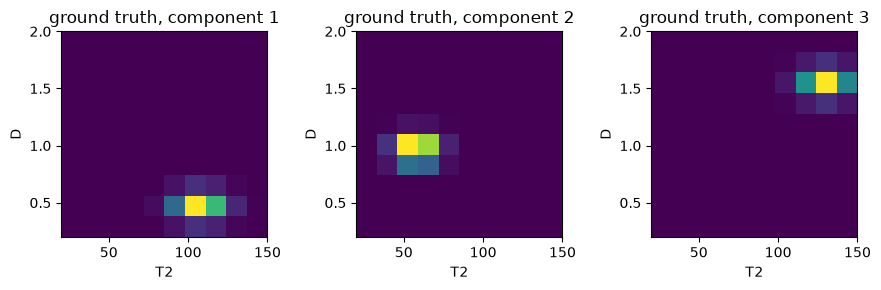

In [3]:

# Define spectra
Dmin,Dmax,nD=.2,2,10
D_vals=np.linspace(Dmin,Dmax,nD); 
T2min,T2max,nT2=20,150,10
T2_vals=np.linspace(T2min,T2max,nT2)

# Define acquisition parameters
bmin,bmax,nb=0,10,20
b_vals=np.linspace(bmin,bmax,nb)
TEmin,TEmax,nTE=10,200,20
TE_vals=np.linspace(TEmin,TEmax,nTE)

# Define fitting parameters
K=3; # Number of canonical spectra
V=12; # Number of voxels
R=8   # Rank for SVD    


# Create spectral grid
D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2); 

# Create A matrix
A = create_A_matrix(D,T2,bmin,bmax,nb,TEmin,TEmax,nTE); 

# Create true C - canonical spectra
# Here have hardcoded centres
C_true=create_gaussian_compartments(D,T2,[.4,.95,1.6],[.1]*K,[110,55,135],[12,10,12])

# Define GT weights
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)

# Set scale parameter
M0_true=np.ones(V)*300;

# Calulate the signal Y = M0 * A * C_true * W_true
SNR = 50
sigma = M0_true/SNR # sigma needs to scale with M0
Y=create_signal(A,C_true,W_true,M0_true,sigma,rng)

# Create GT C_small using SVD
U,s,Vmat=apply_SVD_to_A(A,R)
C_small_true=project_C_to_C_small(C_true,s,Vmat)
#C_small_true = np.diag(s) @ V_mat.T @ C_true - should be equivalent

show_canonical_spectra([('ground truth', C_true)])


#### Run optimisation

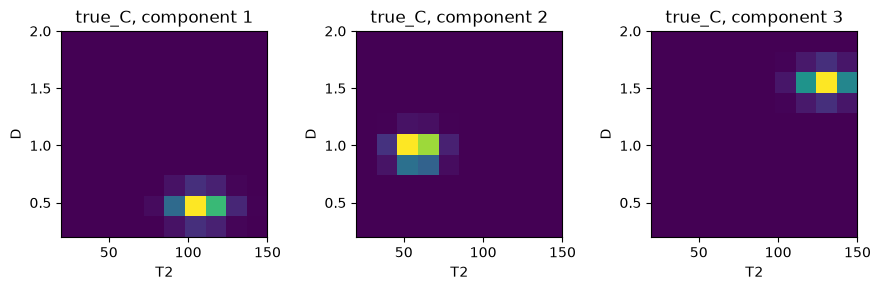

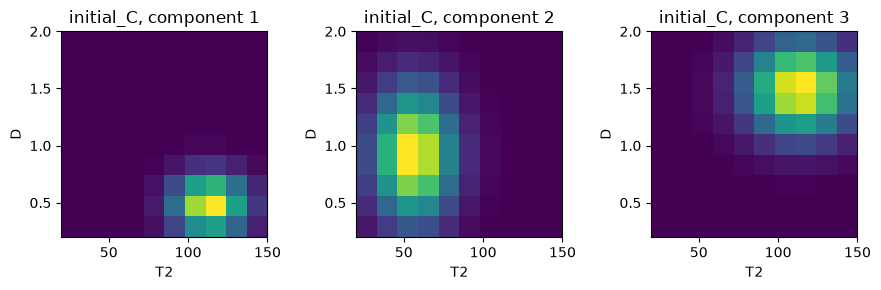

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Initial M0: [279.61489577 296.28959107 296.30582503 291.71989751 294.82143692
 283.42489696 287.89021493 301.20892301 297.22525441 286.81687641
 288.55738563 292.60116868]


In [4]:
# Set intial conditions
C0=define_initial_C_NNLS(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)



iter 0: loss=2386.9567, fit_err=172454.145475, sigma2=36.000000
iter 1: loss=2384.6705, fit_err=172293.197771, sigma2=36.000000
iter 2: loss=2383.5026, fit_err=172209.133552, sigma2=36.000000
iter 3: loss=2382.5392, fit_err=172139.821879, sigma2=36.000000
iter 4: loss=2381.6962, fit_err=172079.184706, sigma2=36.000000
iter 5: loss=2380.9560, fit_err=172025.955476, sigma2=36.000000
iter 6: loss=2380.3018, fit_err=171978.910246, sigma2=36.000000
iter 7: loss=2379.6638, fit_err=171933.030141, sigma2=36.000000
iter 8: loss=2379.2334, fit_err=171902.082181, sigma2=36.000000
iter 9: loss=2378.9212, fit_err=171879.666194, sigma2=36.000000
iter 10: loss=2378.6911, fit_err=171863.150977, sigma2=36.000000
iter 11: loss=2378.5195, fit_err=171850.837450, sigma2=36.000000
iter 12: loss=2378.3914, fit_err=171841.646950, sigma2=36.000000
iter 13: loss=2378.2965, fit_err=171834.842938, sigma2=36.000000
iter 14: loss=2378.2340, fit_err=171830.368993, sigma2=36.000000
iter 15: loss=2378.1979, fit_err=17

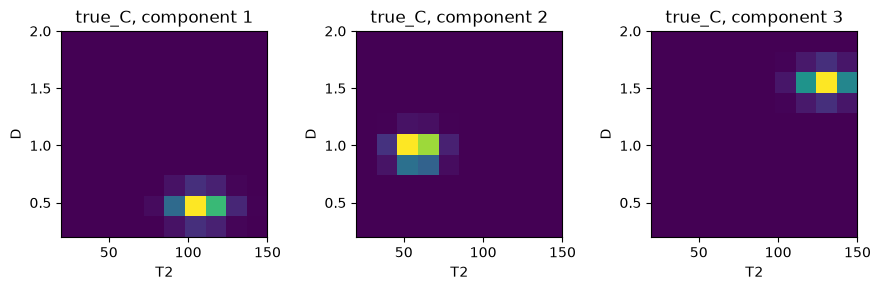

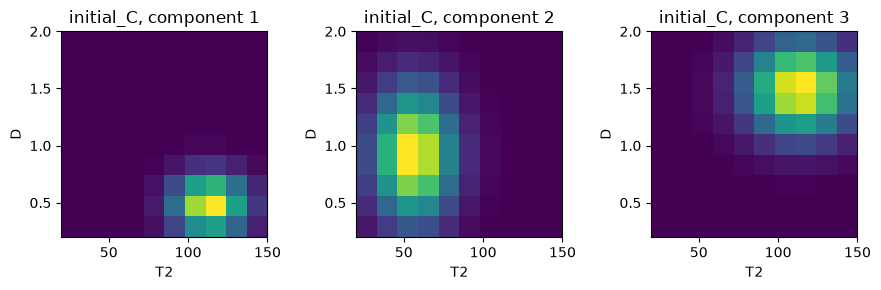

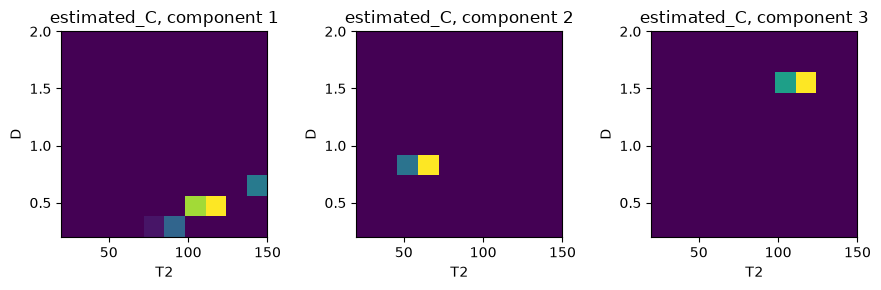

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [279.62793092 296.29976737 296.30836408 291.72341643 294.821308
 283.43530884 287.8937311  301.2072938  297.23255728 286.83309024
 288.56326546 292.60645299]


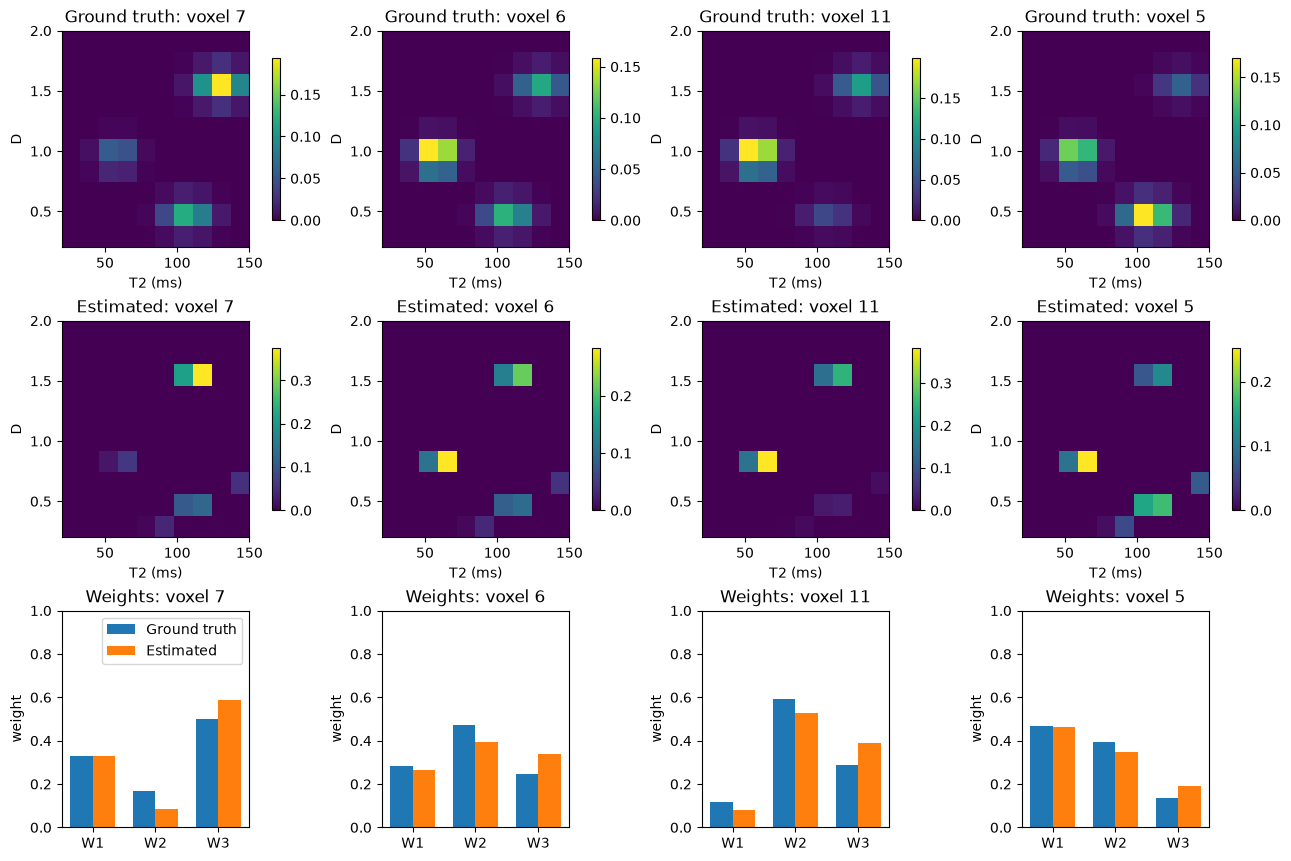

In [ ]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=20,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # IDEALLY WE WANT TO NOT HAVE THIS, OR HAVE THE MODEL FAIRLY INSENSITIVE TO THE NOISE LEVEL BEING A LITTLE WRONG
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=0.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))




Note this constrained optimisation of C (not C_small) has several constraint options:

- c_smoothness
Makes each canonical D–T2 spectrum spatially smooth across neighbouring grid cells.

- c_sparsity
Encourages each canonical spectrum to concentrate its mass into fewer grid locations.

- c_diversity
Discourages different canonical spectra from overlapping at the same D–T2 locations.

Other constraints already in the model (not on C):

- C simplex constraint
Each canonical spectrum is non-negative and sums to one.

- W simplex constraint
Each voxel’s component weights are non-negative and sum to one.

- M0 > 0
Voxel signal scale cannot be negative.

- lam
Ridge/Gaussian penalty on reduced C_small; shrinks its overall magnitude. Not physical D–T2 smoothness.

- Dirichlet alpha on W
A probabilistic prior favouring globally more pure (alpha < 1) or more even (alpha > 1) voxel weights.

- weight_entropy
Non-Dirichlet alternative that encourages individual voxel weights to be sparse/dominant.

#### We can make C smoother with the smoothness option

iter 0: loss=2386.0962, fit_err=172288.172804, sigma2=36.000000
iter 1: loss=2384.1993, fit_err=172154.743235, sigma2=36.000000
iter 2: loss=2383.0694, fit_err=172072.154863, sigma2=36.000000
iter 3: loss=2382.1573, fit_err=172013.862253, sigma2=36.000000
iter 4: loss=2381.3723, fit_err=171958.458968, sigma2=36.000000
iter 5: loss=2380.6728, fit_err=171912.323798, sigma2=36.000000
iter 6: loss=2380.0702, fit_err=171869.447526, sigma2=36.000000
iter 7: loss=2379.5414, fit_err=171832.192179, sigma2=36.000000
iter 8: loss=2379.0770, fit_err=171799.105810, sigma2=36.000000
iter 9: loss=2378.6696, fit_err=171770.069664, sigma2=36.000000
iter 10: loss=2378.2521, fit_err=171748.989813, sigma2=36.000000
iter 11: loss=2377.8096, fit_err=171720.095753, sigma2=36.000000
iter 12: loss=2377.5036, fit_err=171699.096003, sigma2=36.000000
iter 13: loss=2376.8409, fit_err=171651.443055, sigma2=36.000000
iter 14: loss=2376.4817, fit_err=171622.518400, sigma2=36.000000
iter 15: loss=2376.2240, fit_err=17

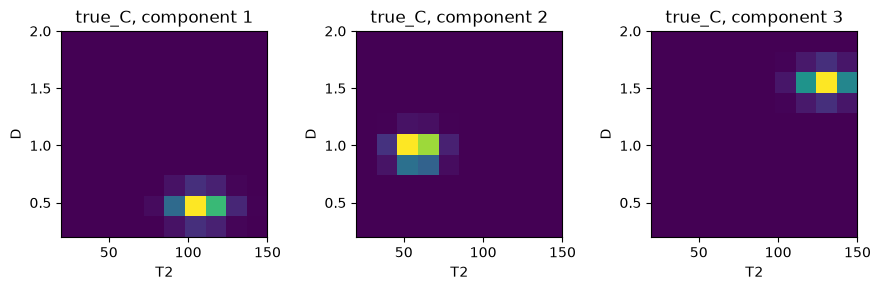

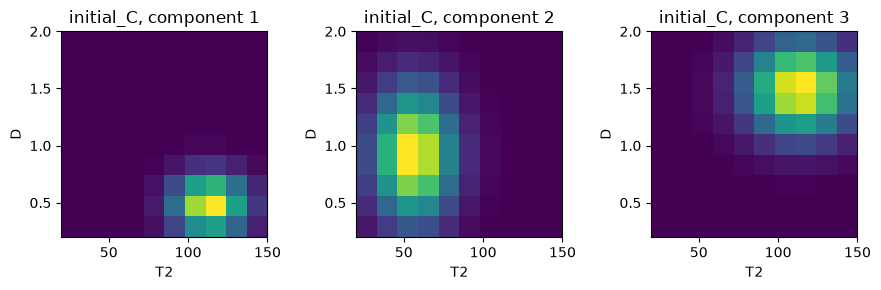

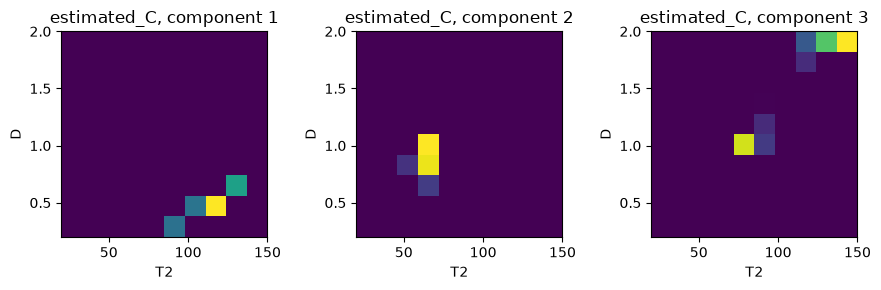

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [279.62797592 296.30046623 296.30655843 291.72435865 294.82523893
 283.43503628 287.8937687  301.20869393 297.23322602 286.83293379
 288.56313422 292.60636688]


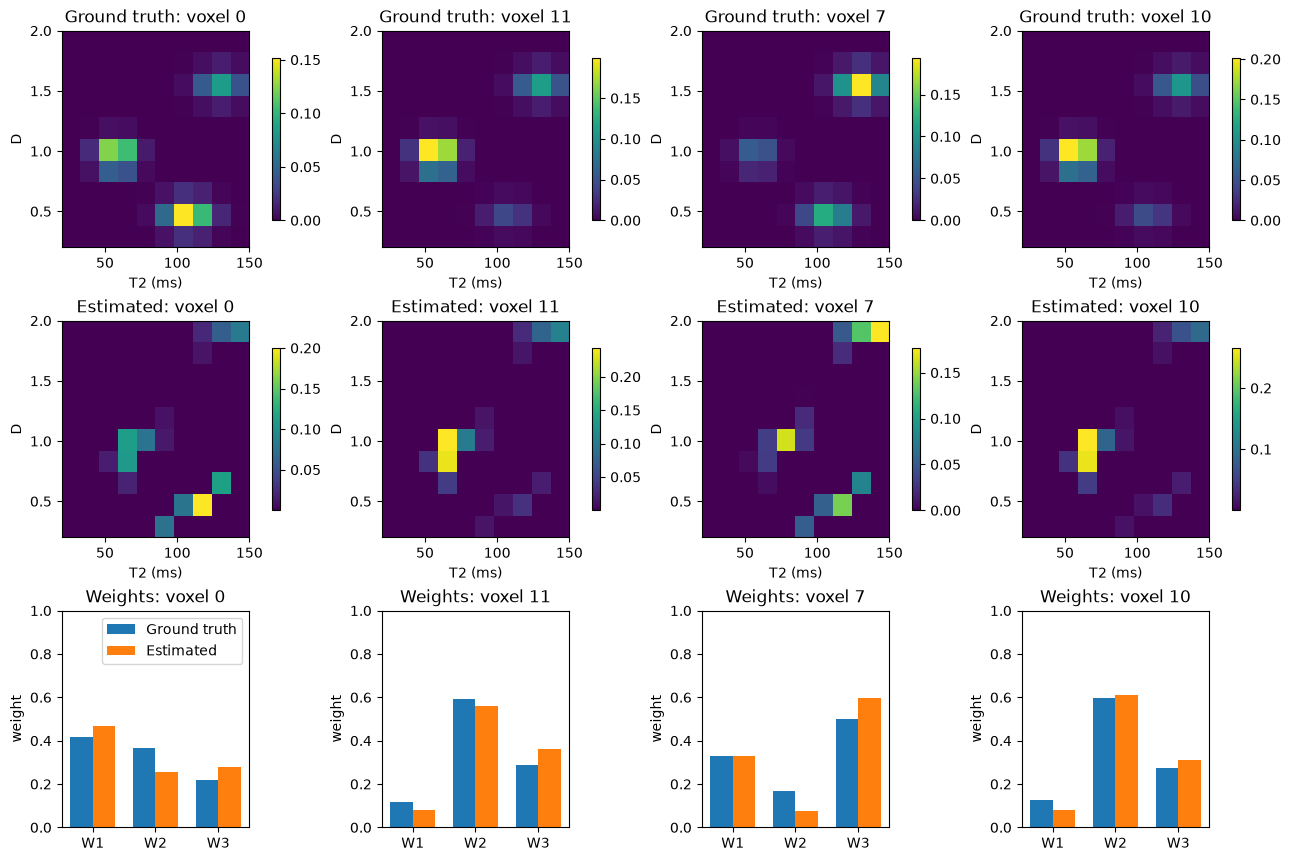

In [ ]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=20,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here
        
        c_sparsity=0.0,            # make C sparse
        c_smoothness=1.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))


#### or sparse

iter 0: loss=2393.8099, fit_err=172745.526088, sigma2=36.000000
iter 1: loss=2389.7864, fit_err=172463.184478, sigma2=36.000000
iter 2: loss=2388.2225, fit_err=172357.050134, sigma2=36.000000
iter 3: loss=2386.9192, fit_err=172271.947471, sigma2=36.000000
iter 4: loss=2385.7524, fit_err=172200.842021, sigma2=36.000000
iter 5: loss=2384.8237, fit_err=172141.579231, sigma2=36.000000
iter 6: loss=2384.0409, fit_err=172094.202056, sigma2=36.000000
iter 7: loss=2383.4956, fit_err=172057.609565, sigma2=36.000000
iter 8: loss=2383.1017, fit_err=172032.013772, sigma2=36.000000
iter 9: loss=2382.7987, fit_err=172012.908107, sigma2=36.000000
iter 10: loss=2382.5635, fit_err=171998.555847, sigma2=36.000000
iter 11: loss=2382.3795, fit_err=171987.748040, sigma2=36.000000
iter 12: loss=2382.2348, fit_err=171979.593633, sigma2=36.000000
iter 13: loss=2382.1205, fit_err=171973.462540, sigma2=36.000000
iter 14: loss=2382.0299, fit_err=171968.876851, sigma2=36.000000
iter 15: loss=2381.9579, fit_err=17

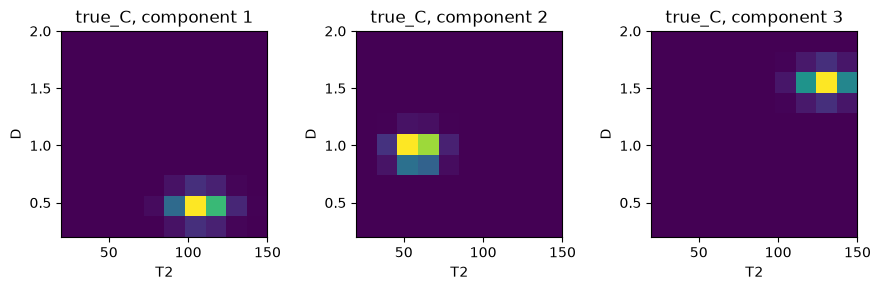

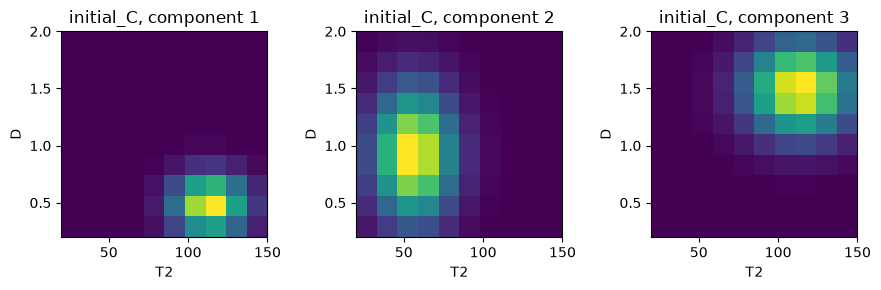

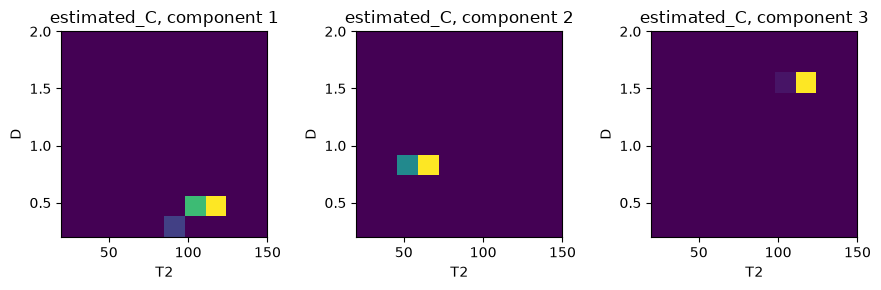

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [279.62819227 296.29943424 296.31138819 291.72340474 294.81648553
 283.43583594 287.89402995 301.20691419 297.23257203 286.8332709
 288.56379078 292.60692162]


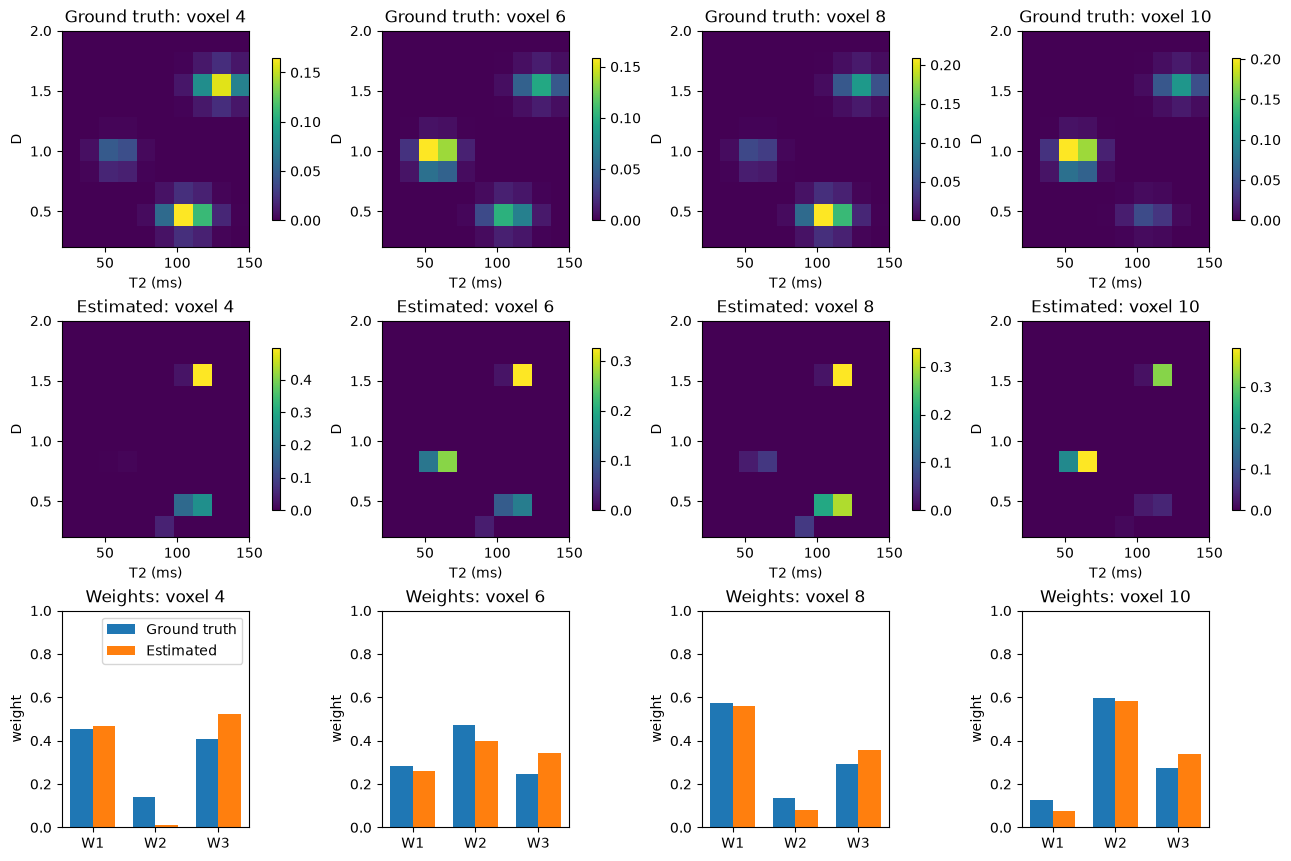

In [ ]:


W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=20,
        sigma2=np.mean(sigma**2),      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=0.0,        # do not combine with entropy here

        c_sparsity=1.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))


#### This looks pretty good
Some notes:

We have simplex constraints on C and W.
C is shared across voxels making it heirarchical
Initialisation of C, M0 and W is good, giving a very good baseline.
You can make C smoother or sparser by adding additional constraints.

You do not need a Dirichlet prior on W for this to be described as a hierarchical Bayesian MAP model.
With:
alpha = 1.0
update_alpha_flag = False
The weight prior is effectively uniform over the simplex. That is a valid weak prior and is a good baseline for basic recovery.

You can set weight_entropy>0 to make W have a sparist-favouring prior. This might be helpful for harder optimisations.

m0_prior = M0_init
m0_prior_sigma = 0.15
<-- This sets M0 to be around an initial value which is estimated using a monoexpoential fit. sigma gives the spread around the initial value


# 2. How about estimating C_small

iter 0: loss=2357.5573, fit_err=170337.382773, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2355.8048, fit_err=170216.539265, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2355.5149, fit_err=170195.664392, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2355.4394, fit_err=170190.204188, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2355.4083, fit_err=170187.953333, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2355.3900, fit_err=170186.626129, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 6: loss=2355.3776, fit_err=170185.724655, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 7: loss=2355.3689, fit_err=170185.086222, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 8: loss=2355.3626, fit_err=170184.627961, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 9: loss=2355.3580, fit_err=170184.297049, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 10: loss=2355.3547, fit_err=170184.057285, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 11: 

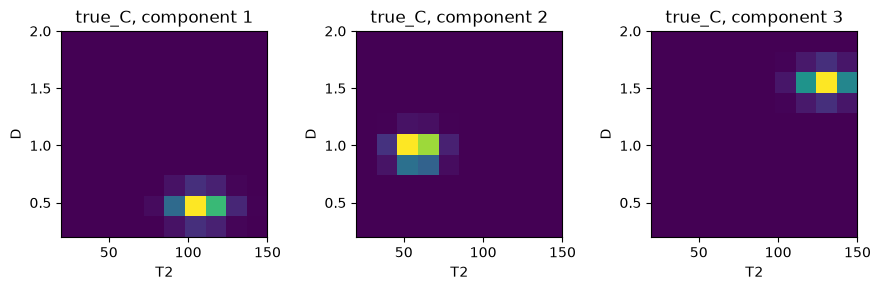

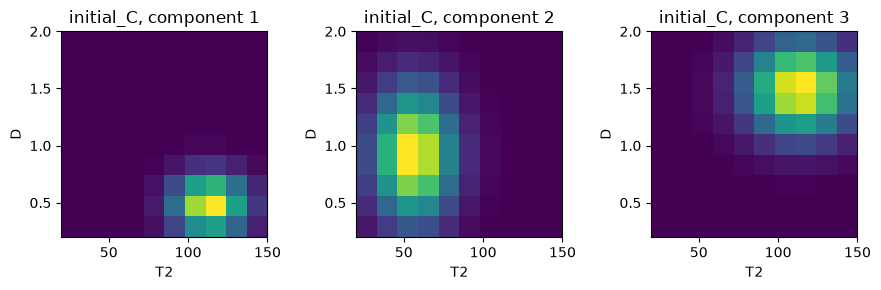

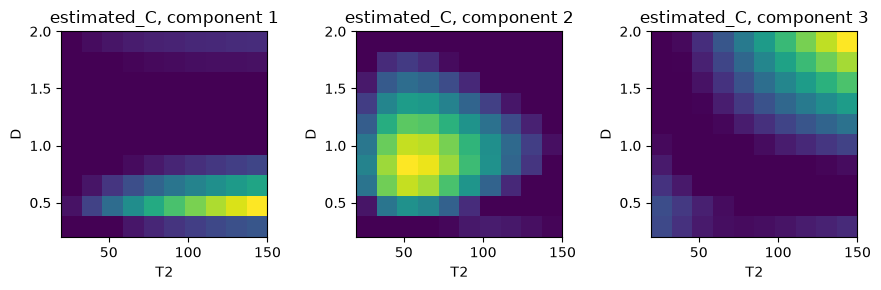

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [279.62103335 296.2920229  296.29508053 291.72111269 294.82260776
 283.42460151 287.8860723  301.20875445 297.22674542 286.82374455
 288.55463552 292.60033357]


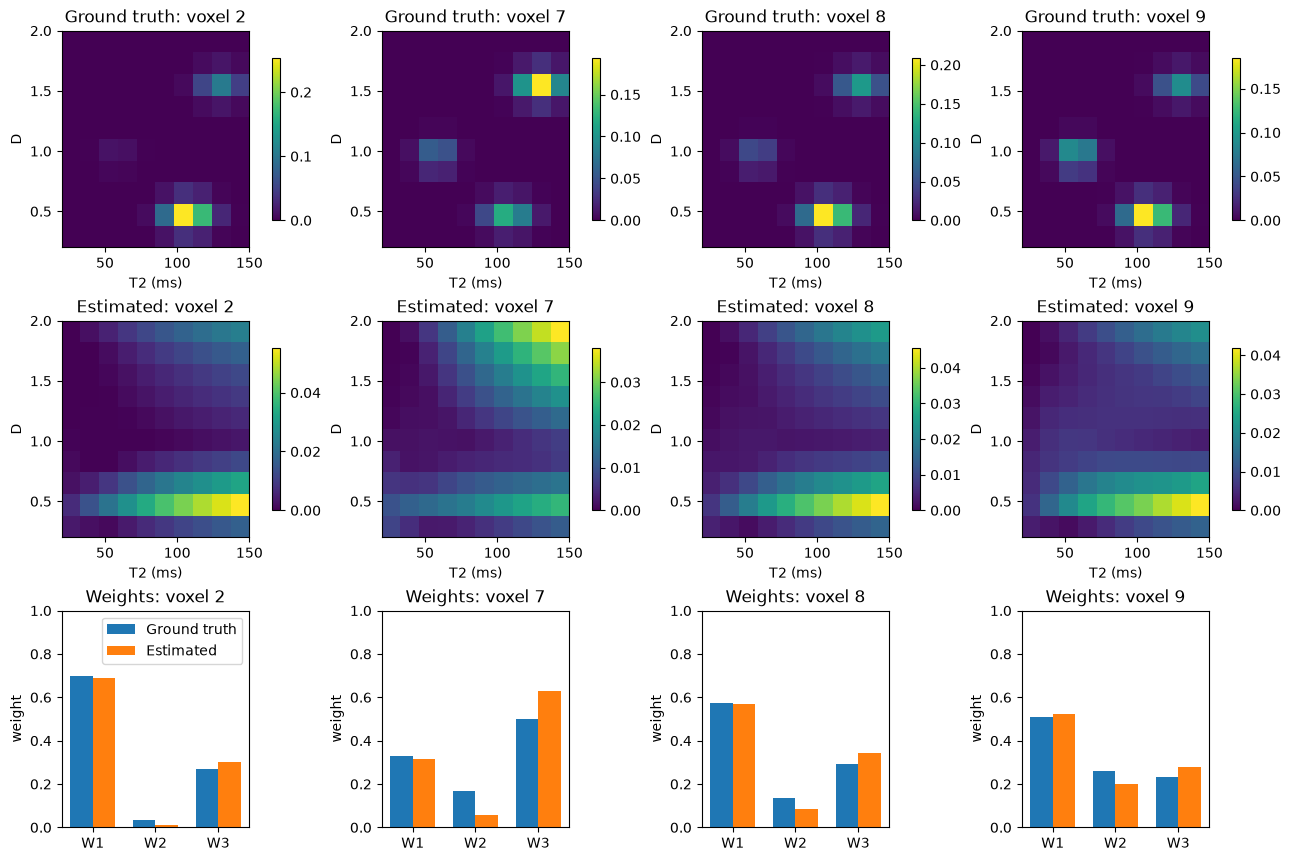

In [ ]:
# CODE AT THE TOP HERE SO YOU CAN TRY DIFFERENT RANKS
R = 8
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


# Here we use run_optimisation not run_optimisation_constrained 
W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)

C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))




#### The spectra are a bit dodgy - can change R to adjust this, but the weights actually look quite good regardless. Could fit peaks afterwards?

## 3. What happens if you set a Drichilet prior and try to estimate W and C_small?
Trying to recreate Maria's issues

iter 0: loss=2357.5573, fit_err=170337.382773, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2355.8048, fit_err=170216.539265, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2355.5149, fit_err=170195.664392, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2355.4394, fit_err=170190.204188, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2355.4083, fit_err=170187.953333, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2355.3405, fit_err=170186.626129, sigma2=36.000000, lam=0.0000, alpha=1.0820
iter 6: loss=2355.3286, fit_err=170185.780755, sigma2=36.000000, lam=0.0000, alpha=1.0822
iter 7: loss=2355.3207, fit_err=170185.189493, sigma2=36.000000, lam=0.0000, alpha=1.0820
iter 8: loss=2355.3151, fit_err=170184.758041, sigma2=36.000000, lam=0.0000, alpha=1.0818
iter 9: loss=2355.3110, fit_err=170184.439895, sigma2=36.000000, lam=0.0000, alpha=1.0815
iter 10: loss=2355.3081, fit_err=170184.203921, sigma2=36.000000, lam=0.0000, alpha=1.0812
iter 11: 

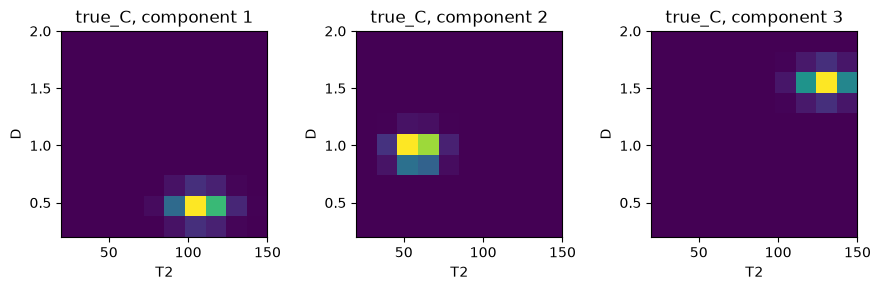

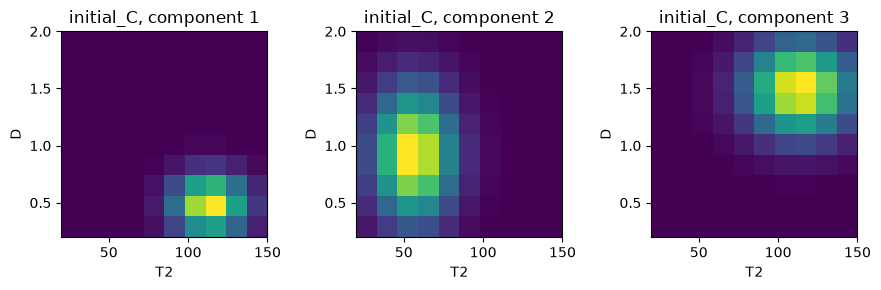

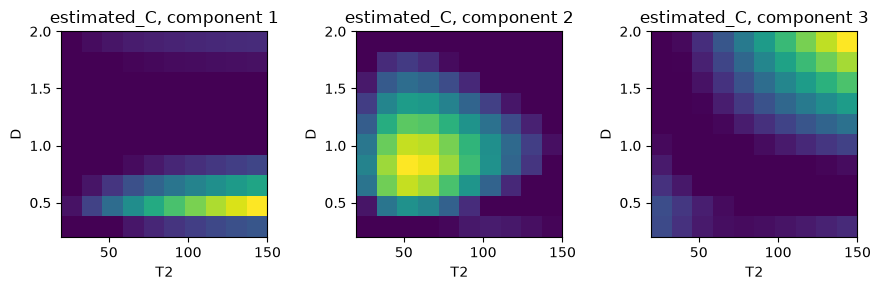

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [279.62105283 296.29197269 296.29510837 291.72106397 294.82246425
 283.42460988 287.88606821 301.20887065 297.22681169 286.82376567
 288.55460322 292.60030268]


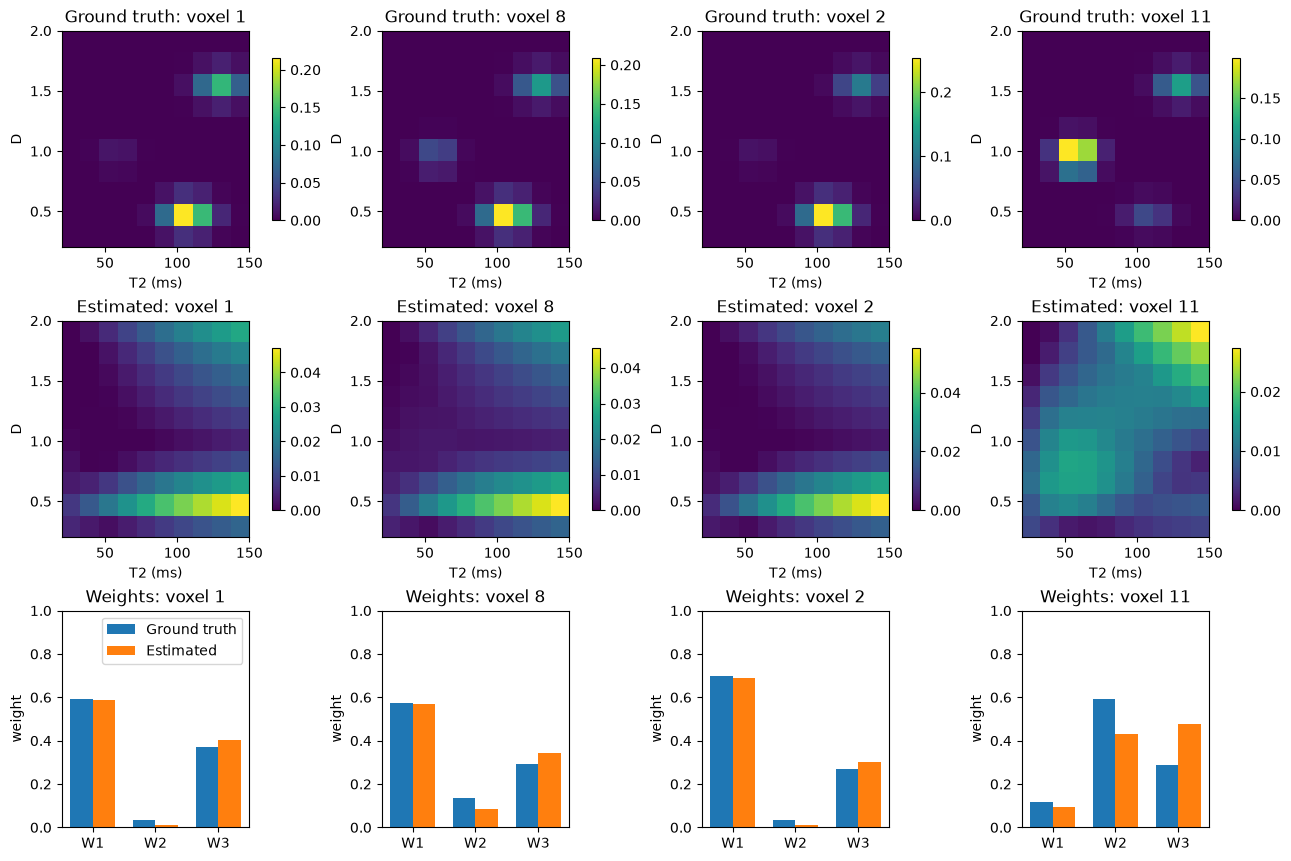

In [ ]:
# 

R = 8
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

print("W MAE:", np.mean(np.abs(W_true - W_est)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est)))
print("C MAE:", np.mean(np.abs(C_true - C_est)))
print("alpha:", alpha_est)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])

print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))




#### This also seems to work - our spectra are blurred but we recover the wieghts well and we can postprocess the spectra. 

Note, the GT fibre fractions are not drawn from a Dirichlet distribution, do there is no "GT" alpha, but this optimisation uses Dirichlet as a regulariser.

### Let's try with a GT alpha to see if we can recover this also

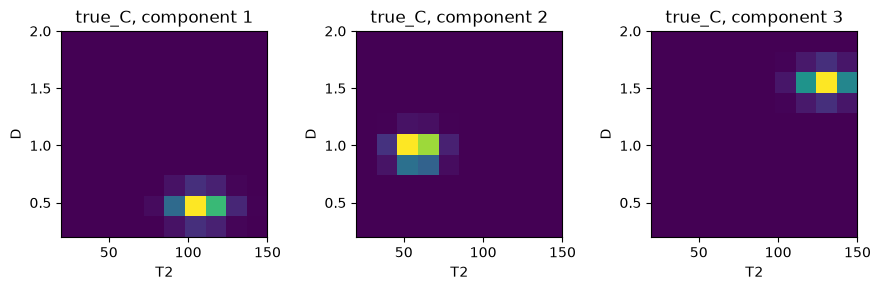

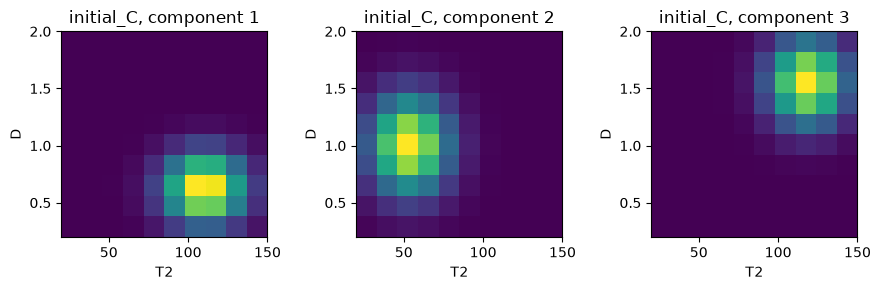

iter 0: loss=2498.2176, fit_err=180427.426496, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2450.1502, fit_err=177005.094668, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2447.1984, fit_err=176796.478369, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2447.0643, fit_err=176787.029633, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2447.0553, fit_err=176786.389320, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2446.6054, fit_err=176786.286778, sigma2=36.000000, lam=0.0000, alpha=0.8020
iter 6: loss=2446.6024, fit_err=176786.434644, sigma2=36.000000, lam=0.0000, alpha=0.8011
iter 7: loss=2446.6012, fit_err=176786.534813, sigma2=36.000000, lam=0.0000, alpha=0.8006
iter 8: loss=2446.6004, fit_err=176786.573063, sigma2=36.000000, lam=0.0000, alpha=0.8003
iter 9: loss=2446.5996, fit_err=176786.614352, sigma2=36.000000, lam=0.0000, alpha=0.8001
iter 10: loss=2446.5989, fit_err=176786.624896, sigma2=36.000000, lam=0.0000, alpha=0.7999
iter 11: 

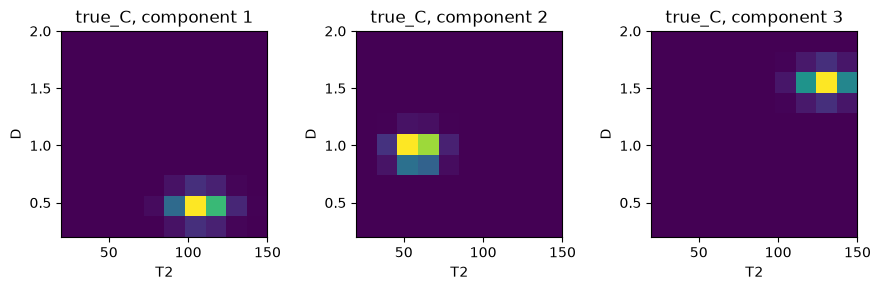

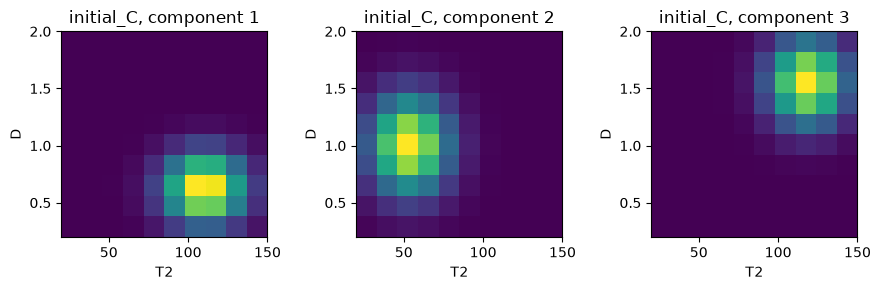

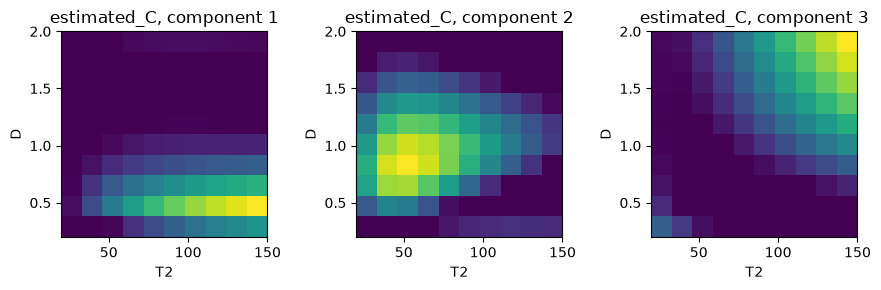

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [287.30177323 286.899883   290.8495788  278.90153025 279.09594634
 298.17263882 297.26135256 300.38039118 295.12443982 291.45818441
 298.90955159 285.2741222 ]


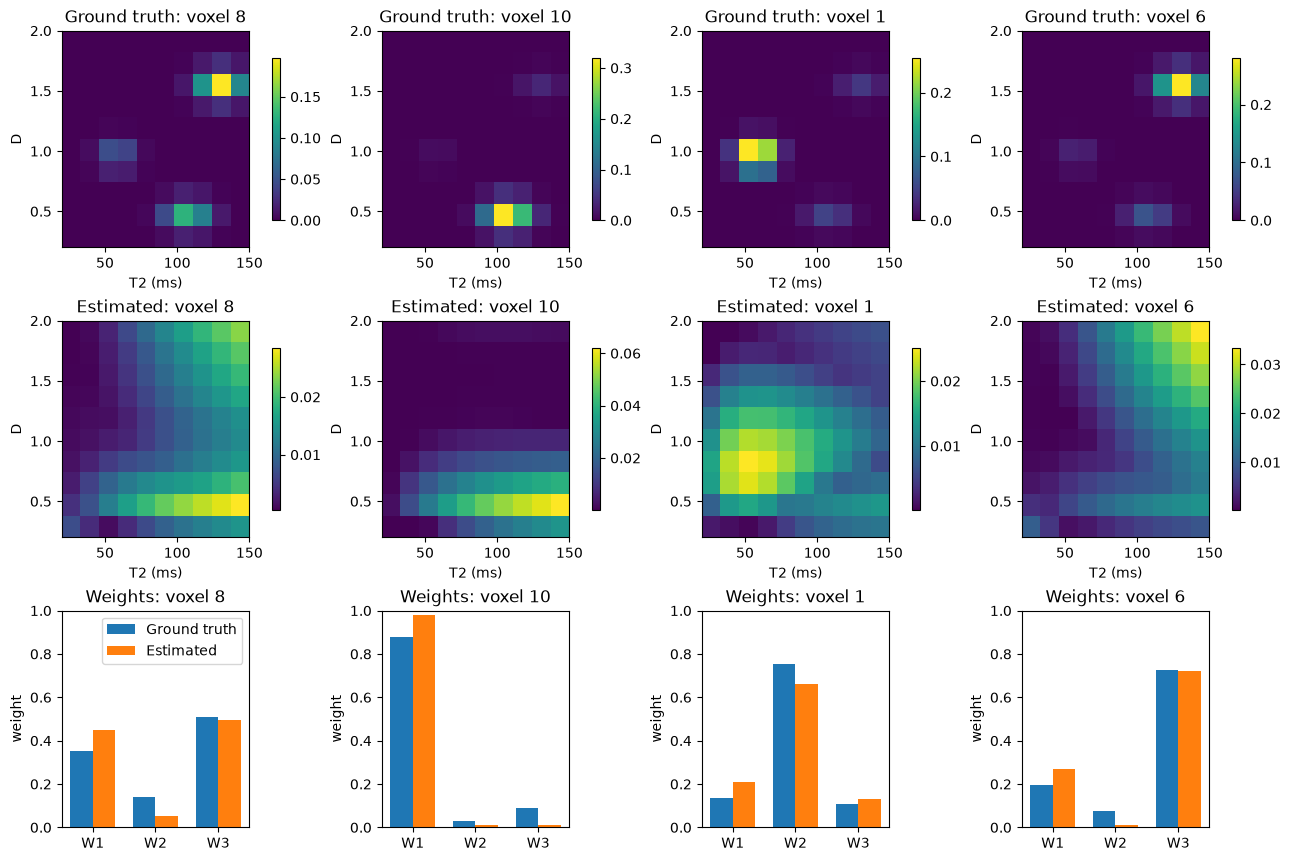

In [ ]:
alpha_true = 0.5
W_true_dirichlet = rng.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 8
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est_dirichlet, M0_est_dirichlet, Csmall_est_dirichlet, alpha_est_dirichlet, sigma2_est_dirichlet, lam_est_dirichlet, losses_dirichlet, fit_errs_dirichlet = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first
        #weight_entropy=0.0,        # do not combine with entropy here
        
        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est_dirichlet = estimate_C(Vmat, s, Csmall_est_dirichlet)
C_est_dirichlet, W_est_dirichlet = order_components(C_true, C_est_dirichlet, W_est_dirichlet, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est_dirichlet @ W_est_dirichlet

print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est_dirichlet)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est_dirichlet)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show=rng.choice(V, size=4, replace=False))






#### alpha isnt reconstructed perfectly but it does track with GT (e.g. estimated=0.3 when GT=0.1, and estimated = 5 when GT=10)

This also looks reasonable

## 4. An alternative to alpha

Instead of using a Dirichlet prior, we could instead have an entropy prior on the weights. With lower entropy, more voxels have sparse weights, whilst still obeying the simplex constraint.

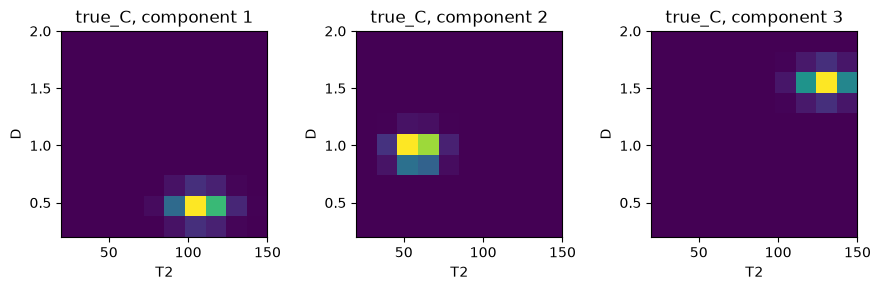

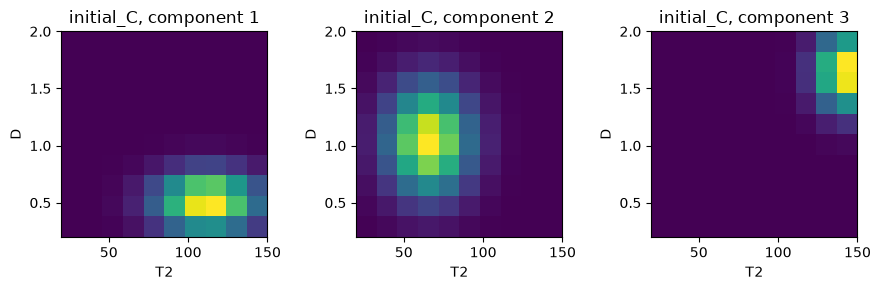

iter 0: loss=2501.5497, fit_err=174233.258603, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 1: loss=2491.6643, fit_err=173495.196033, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 2: loss=2490.7903, fit_err=173451.856850, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 3: loss=2490.3893, fit_err=173452.212260, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 4: loss=2490.1989, fit_err=173453.406598, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 5: loss=2490.0574, fit_err=173455.773652, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 6: loss=2489.9591, fit_err=173458.906217, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 7: loss=2489.8842, fit_err=173462.481167, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 8: loss=2489.8260, fit_err=173466.308057, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 9: loss=2489.7802, fit_err=173470.225707, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 10: loss=2489.7435, fit_err=173474.123940, sigma2=36.000000, lam=0.0000, alpha=1.0000
iter 11: 

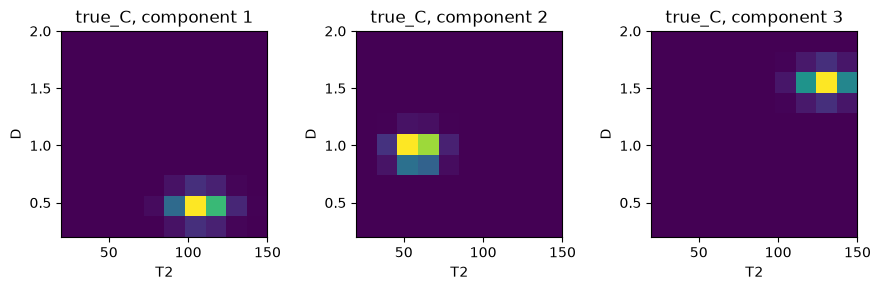

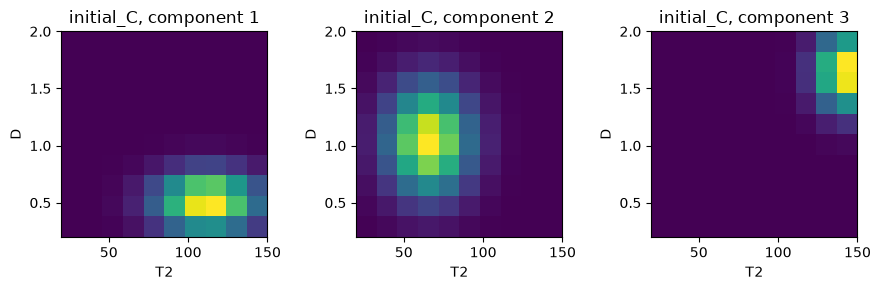

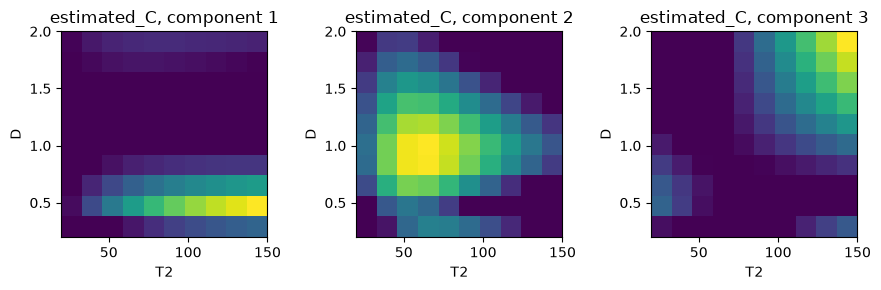

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [276.67699757 295.66958053 298.43899077 286.89364187 295.67794341
 290.24461608 280.2087832  296.88279455 283.54262921 296.59839959
 286.8143236  290.47910902]


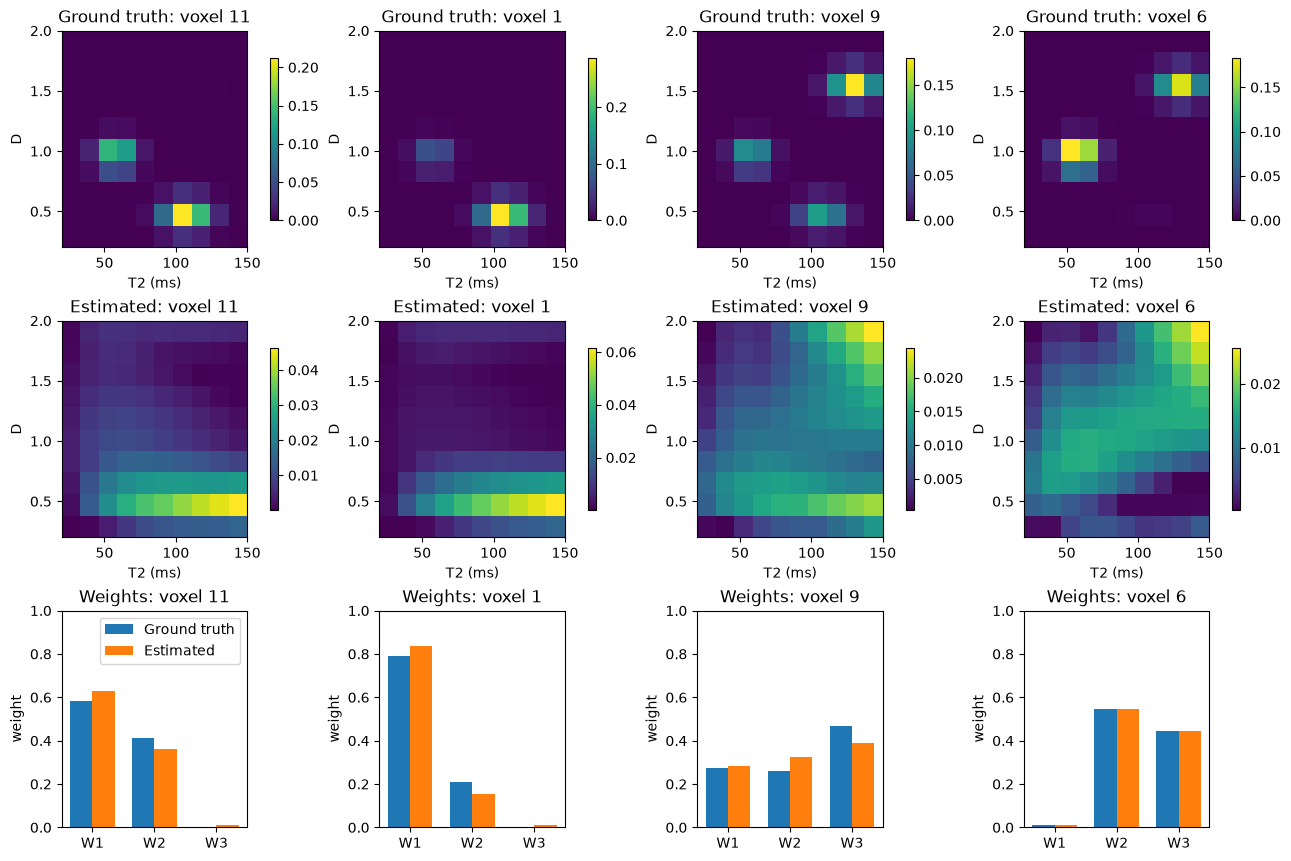

In [17]:
# Here initilise with Dirichlet-distributed weights with alpha<1 to make sparse wieghts, but optimise not assuming Dirichlet

alpha_true = 0.5
W_true_dirichlet = rng.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 8
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=np.mean(sigma**2),
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first
        weight_entropy=10.0,        

        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est @ W_est

# print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
# print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
# print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
# print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))






#### This doesnt seem to make a big difference? the weights are well estimated with entropy=0. Leaving in as an option